In [117]:
import os
import sys
import h5py
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import time
from tqdm import tqdm

In [118]:
#load file
#subhalo_file  = r"/scratch/gent/472/vsc47210/TNG100-1_subhalosCat.hdf5"  # put your group catalog here if available

#load file locally
subhalo_file = r"C:\Users\grego\Downloads\TNG100-1_subhalosCat.hdf5 (1)\TNG100-1_subhalosCat.hdf5"

In [119]:
data = h5py.File(subhalo_file, 'r')
data.keys()


<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'Subhalo']>

In [120]:
#All attributes
print("Header")
for x in list(data['Header'].attrs):
    print(f'The value for {x} is: {data['Header'].attrs[x]}')


print("Parameters")
for x in list(data['Parameters'].attrs):
    print(f'The value for {x} is: {data['Parameters'].attrs[x]}')

print("Subhalo")
for x in list(data['Subhalo'].attrs):
    print(f'The value for {x} is: {data['Subhalo'].attrs[x]}')

Header
The value for BoxSize is: 75000.0
The value for HubbleParam is: 0.6774
The value for Nsubgroups_Total is: 4371211
The value for Omega0 is: 0.3089
The value for OmegaLambda is: 0.6911
The value for Redshift is: 2.220446049250313e-16
The value for Time is: 0.9999999999999998
Parameters
The value for AGB_MassTransferOn is: 1
The value for ActivePartFracForNewDomainDecomp is: 0.003
The value for AdaptiveHydroSofteningSpacing is: 1.2
The value for BlackHoleAccretionFactor is: 1.0
The value for BlackHoleCenteringMassMultiplier is: 1000.0
The value for BlackHoleEddingtonFactor is: 1.0
The value for BlackHoleFeedbackFactor is: 0.1
The value for BlackHoleMaxAccretionRadius is: 1e+20
The value for BlackHoleRadiativeEfficiency is: 0.2
The value for BoxSize is: 75000.0
The value for CellMaxAngleFactor is: 2.25
The value for CellShapingSpeed is: 0.5
The value for ComovingIntegrationOn is: 1
The value for CoolingOn is: 1
The value for CoolingTablePath is: b'L75TNG_Arepo_GFM_Tables/Cooling/coo

In [121]:
#information on subhalos

for el in list(data['Subhalo'].keys()):
    print(f"The value of {el} is: {data['Subhalo'][el]}")

The value of SubhaloBHMass is: <HDF5 dataset "SubhaloBHMass": shape (4371211,), type "<f4">
The value of SubhaloBHMdot is: <HDF5 dataset "SubhaloBHMdot": shape (4371211,), type "<f4">
The value of SubhaloBfldDisk is: <HDF5 dataset "SubhaloBfldDisk": shape (4371211,), type "<f4">
The value of SubhaloBfldHalo is: <HDF5 dataset "SubhaloBfldHalo": shape (4371211,), type "<f4">
The value of SubhaloCM is: <HDF5 dataset "SubhaloCM": shape (4371211, 3), type "<f4">
The value of SubhaloFlag is: <HDF5 dataset "SubhaloFlag": shape (4371211,), type "|b1">
The value of SubhaloGasMetalFractions is: <HDF5 dataset "SubhaloGasMetalFractions": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsHalfRad is: <HDF5 dataset "SubhaloGasMetalFractionsHalfRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsMaxRad is: <HDF5 dataset "SubhaloGasMetalFractionsMaxRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsSfr is: <HDF5 dataset "SubhaloGasMet

In [122]:
#extract useful data
h = data['Header'].attrs['HubbleParam'] #Hubble parameter
boxsize = data['Header'].attrs['BoxSize']/h #boxsize in comoving kpc (~110MPc)
mask   = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8) #consider for analysis (halo is suitable for analysis)
positions = np.asarray(data['Subhalo']['SubhaloPos'])/h #kpc most bound particle
COM = np.asarray(data['Subhalo']['SubhaloCM'])/h #COM of halos
total_mass_type = np.asarray(data['Subhalo']["SubhaloMassType"][:])*10**10/h # Total Mass of all bound particles per type
total_mass  = np.asarray(data['Subhalo']["SubhaloMass"][:])*10**10/h  #Total mass of all particles all types combined
subhalo_len = np.asarray(data['Subhalo']["SubhaloLen"][:]) #Total number of member particle/cells in this Subhalo, of all types.
subhalo_parents = np.asarray(data['Subhalo']['SubhaloParent'])
subhalo_grnr = np.asarray(data['Subhalo']['SubhaloGrNr'])
print(len(positions[:,0]))

#only take suitable for analysis (mask 1)
positions = positions[mask==1]
COM = COM[mask == 1]
total_mass_type = total_mass_type[mask == 1]
total_mass = total_mass[mask == 1]
subhalo_len = subhalo_len[mask == 1]
subhalo_parents = subhalo_parents[mask == 1]
subhalo_grnr = subhalo_grnr[mask == 1]

print(len(positions[:,0]))

4371211
4361030


In [123]:
from numba import njit, prange

@njit(fastmath=True)
def distance_periodic(x1, y1, z1, x2, y2, z2, boxsize):
    dx = x2 - x1 #x-distance between 2 points
    dy = y2 - y1
    dz = z2 - z1
    dx -= boxsize * np.rint(dx / boxsize) #rint == round to nearest integer, due to periodic box
    dy -= boxsize * np.rint(dy / boxsize)
    dz -= boxsize * np.rint(dz / boxsize)
    return np.sqrt(dx*dx + dy*dy + dz*dz) #distance between 2 points 1 and 2

@njit(parallel=True, fastmath=True)
def count_pairs_sample_queries(x, y, z, rbins, cell_ids, cell_starts, cell_ends, neighbors, query_indices, boxsize):
    """
    For each index i in query_indices (indices into full x,y,z arrays),
    count ALL neighbors j != i from the full arrays using neighbor cells.
    This returns counts summed over all queries (NOT unique unordered pairs).
    """
    nbins = len(rbins) - 1
    counts = np.zeros(nbins, dtype=np.int64)

    for qq in prange(len(query_indices)): #parallel range (for numba)
        i = query_indices[qq]
        xi, yi, zi = x[i], y[i], z[i]
        ci = cell_ids[i]

        # loop over neighbor cells
        for cj in neighbors[ci]:
            start_j = cell_starts[cj]
            end_j = cell_ends[cj]

            for j in range(start_j, end_j):
                if j == i:  # skip self
                    continue
                r = distance_periodic(xi, yi, zi, x[j], y[j], z[j], boxsize)
                b = np.searchsorted(rbins, r) - 1
                counts[b] += 1
    return counts

def two_point_neighborlist_downsampled(positions, rbins, boxsize, Nmax=100000, verbose=True):
    """
    Neighbor-list two-point correlation with global downsampling:
    - build neighbor lists on full positions
    - randomly sample up to Nmax query particles
    - for each sampled query count ALL neighbors in full set (j != i)
    - RR uses N (full) and N_samp correctly
    Returns dict with xi, DD_counts, RR_counts, rbins
    """
    N = positions.shape[0]
    if verbose:
        print(f"Total N = {N}; rbins: {len(rbins)-1} bins; rmax = {rbins[-1]:.6g}")

    # Downsample
    rng = np.random.default_rng()
    query_indices = rng.choice(N, size=Nmax, replace=False)
    N_samp = Nmax

    # Periodic boundaries 
    x_full = (positions[:,0] % boxsize).astype(np.float64)
    y_full = (positions[:,1] % boxsize).astype(np.float64)
    z_full = (positions[:,2] % boxsize).astype(np.float64)

    # Cell-list parameters
    rmax = rbins[-1]
    nc = max(1, int(np.floor(boxsize / rmax)))
    cell_size = boxsize / nc

    # assign cells
    ix = np.floor(x_full / cell_size).astype(np.int64) % nc
    iy = np.floor(y_full / cell_size).astype(np.int64) % nc
    iz = np.floor(z_full / cell_size).astype(np.int64) % nc
    cell_ids = (ix + iy*nc + iz*nc*nc).astype(np.int64)

    # sort indices by cell to get contiguous ranges
    order = np.argsort(cell_ids)
    x = x_full[order]; y = y_full[order]; z = z_full[order]
    cell_ids_sorted = cell_ids[order]

    # Map original indices -> sorted positions indices 
    inv_order = np.empty_like(order)
    inv_order[order] = np.arange(order.size, dtype=np.int64)
    query_sorted_indices = inv_order[query_indices]

    # compute cell start/end indices
    ncells = nc**3
    cell_starts = np.zeros(ncells, dtype=np.int64)
    cell_ends = np.zeros(ncells, dtype=np.int64)
    for ci in range(ncells):
        # find first/last position belonging to cell ci in sorted arrays
        mask = (cell_ids_sorted == ci)
        locs = np.where(mask)[0]
        if locs.size > 0:
            cell_starts[ci] = locs[0]
            cell_ends[ci] = locs[-1] + 1
        else:
            cell_starts[ci] = 0
            cell_ends[ci] = 0

    # build neighbor list per cell 
    neighbors = []
    for ci in range(ncells):
        cx = ci % nc
        cy = (ci // nc) % nc
        cz = ci // (nc*nc)
        neigh = []
        for dx in (-1,0,1):
            for dy in (-1,0,1):
                for dz in (-1,0,1):
                    nx = (cx + dx) % nc
                    ny = (cy + dy) % nc
                    nz = (cz + dz) % nc
                    neigh_id = nx + ny*nc + nz*nc*nc
                    neigh.append(neigh_id)
        neighbors.append(np.array(neigh, dtype=np.int64))

    if verbose:
        print(f"Built cell-list: nc = {nc}, ncells = {ncells}, N_samp = {N_samp}")

    # Count DD
    t0 = time.time()
    DD_counts = count_pairs_sample_queries(x, y, z, rbins, cell_ids_sorted, cell_starts, cell_ends, neighbors, query_sorted_indices, boxsize)
    t1 = time.time()
    if verbose:
        print(f"DD counted in {t1-t0:.2f} s; total neighbor counts sum = {DD_counts.sum()}")

    # Analytic RR 
    # For each sampled query we expect (N - 1) * (V_shell / V_box) neighbors in that shell,
    # so RR_total = N_samp * (N - 1) * (V_shell / V_box)
    Vbox = boxsize**3
    shell_vol = 4.0/3.0*np.pi*(rbins[1:]**3 - rbins[:-1]**3)
    RR_counts = (N_samp * (N - 1)) * (shell_vol / Vbox)

    with np.errstate(divide='ignore', invalid='ignore'):
        xi = DD_counts / np.maximum(RR_counts, 1e-12) - 1.0

    return dict(xi=xi, DD=DD_counts, RR=RR_counts, rbins=rbins, N=N, N_samp=N_samp)


In [124]:
#Calculate correlation function

# radius bins for clustering
rmin = 0.01 * boxsize
rmax = 0.2 * boxsize #Distances up to 0.5 are physical
nbins = 20
#logbins
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins)
#xires = two_point_neighborlist_downsampled(positions, rbins, boxsize, Nmax=10000, verbose=True)
xires = two_point_neighborlist_downsampled(positions, rbins, boxsize, Nmax=100000, verbose=True) #10^5 points as done in paper
# plot xi with jackknife errors if present
rmid = np.sqrt(rbins[1:] * rbins[:-1])

Total N = 4361030; rbins: 19 bins; rmax = 22143.5
Built cell-list: nc = 5, ncells = 125, N_samp = 100000
DD counted in 1199.92 s; total neighbor counts sum = 13989429458


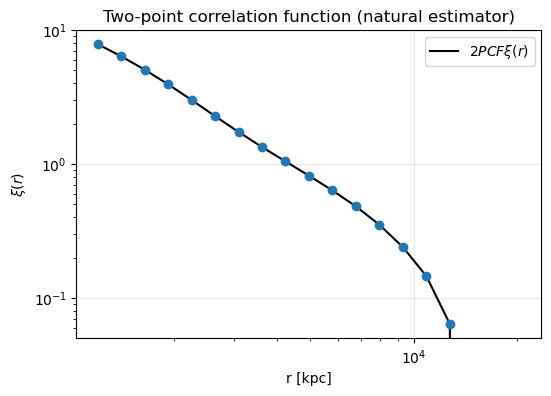

In [163]:
plt.figure(figsize=(6,4))
plt.plot(rmid, xires['xi'], color='black', label=r'$2PCF \xi(r)$')
plt.errorbar(rmid, xires["xi"], fmt='o')
plt.xscale('log'); plt.yscale('log')
plt.xlabel("r [kpc]"); plt.ylabel(r"$\xi(r)$")
plt.title("Two-point correlation function (natural estimator)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

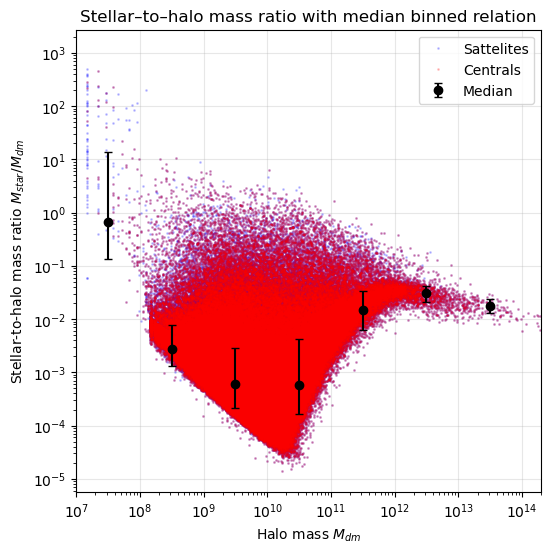

In [126]:
# 1. select valid data
valid = (total_mass > 0) & (total_mass_type[:,1] > 0) & (total_mass_type[:,4] > 0)


Mtot = total_mass[valid]
Mgas = total_mass_type[valid,0]
Mdm  = total_mass_type[valid,1]
Mstar = total_mass_type[valid,4]
Mbh = total_mass_type[valid,5]
parents = subhalo_parents[valid]

# 2. Select centrals with subparents
mask = (parents == 0) #halo is central (dominant subhalo)

Mdm_central = Mdm[mask]
Mstar_central = Mstar[mask]
Mgas_central = Mgas[mask]
Mtot_central = Mtot[mask]

# 3. Build log bins (1 dex is change by factor 10, unit of log) 
bin_width_dex = 1.0

logM_min = np.floor(np.log10(Mdm_central.min())) #floor choses the largest integer smaller than x (2.1 becomes 2)
logM_max = np.ceil(np.log10(Mdm_central.max())) #ceil choses the smallest integer larger than x (2.1 becomes 3)

bin_edges = 10**np.arange(logM_min, logM_max + 1e-9, bin_width_dex)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])


# 4. Compute medians per halo-mass bin
median_ratio = []
sigma_low = []
sigma_high = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]): #go over total mass range through bins

    # CORRECT bin mask (bin in Mdm, not Mstar)
    m = (Mdm_central > lo) & (Mdm_central <= hi) #mass range

    if np.sum(m) < 5: #at least 5 subhaloes in bin m
        median_ratio.append(np.nan)
        sigma_low.append(np.nan)
        sigma_high.append(np.nan)
        continue

    R = Mstar_central[m] / Mdm_central[m] #(M_star/M_dm) for a given mass range m

    med = np.median(R) #not mean because of outliers
    #68% (=84-16) of data falls in 1sigma (Gaussian)
    p16, p84 = np.percentile(R, [16, 84]) #np.percentile(data, q) returns the value below which q percent of the data lies.

    median_ratio.append(med)
    sigma_low.append(med - p16)
    sigma_high.append(p84 - med)

median_ratio = np.array(median_ratio)
sigma_low = np.array(sigma_low)
sigma_high = np.array(sigma_high)


# 5. Plot
plt.figure(figsize=(6,6))

plt.loglog(Mdm, Mstar/Mdm, '.', ms=2, alpha=0.2, color='blue', label = 'Sattelites')
plt.loglog(Mdm_central, Mstar_central/Mdm_central, '.', ms=2, alpha=0.2, color='red', label = 'Centrals')

plt.errorbar(
    bin_centers, median_ratio,
    yerr=[sigma_low, sigma_high],
    fmt='o', color='black', markersize=6, capsize=3,
    label='Median'
)

plt.xlabel(r"Halo mass $M_{dm}$")
plt.xlim(1e7, 2e14)
plt.ylabel(r"Stellar-to-halo mass ratio $M_{star}/M_{dm}$")
plt.title("Stellar–to–halo mass ratio with median binned relation")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


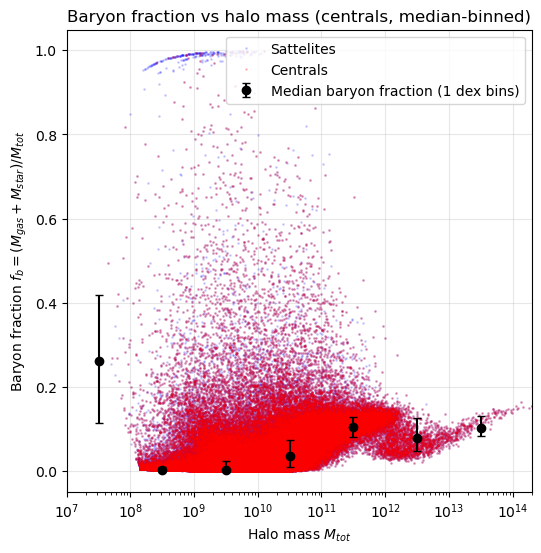

In [81]:
# compute baryon fraction f_b = (Mgas + Mstar)/Mtot for each subhalo

# baryon fraction for centrals
f_b = (Mgas + Mstar) / Mtot
f_b_central = (Mgas_central + Mstar_central) / Mtot_central


#  Logarithmic bins in total mass 
bin_width_dex = 1.0

logM_min = np.floor(np.log10(Mtot_central.min()))
logM_max = np.ceil(np.log10(Mtot_central.max()))

bin_edges   = 10**np.arange(logM_min, logM_max + 1e-9, bin_width_dex)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])


# Compute medians + 1σ scatter per bin
median_fb = []
sigma_low = []
sigma_high = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):

    m = (Mtot_central > lo) & (Mtot_central <= hi)

    if np.sum(m) < 5:
        median_fb.append(np.nan)
        sigma_low.append(np.nan)
        sigma_high.append(np.nan)
        continue

    R = f_b_central[m]   # baryon fraction

    med = np.median(R)
    p16, p84 = np.percentile(R, [16, 84])

    median_fb.append(med)
    sigma_low.append(med - p16)
    sigma_high.append(p84 - med)

median_fb = np.array(median_fb)
sigma_low = np.array(sigma_low)
sigma_high = np.array(sigma_high)


# Plot
plt.figure(figsize=(6,6))

# raw points
plt.semilogx(Mtot, f_b, '.', ms=2, alpha=0.15, color='blue', label = 'Sattelites')
plt.semilogx(Mtot_central, f_b_central, '.', ms=2, alpha=0.2, color='red', label = 'Centrals')

# median + scatter
plt.errorbar(
    bin_centers, median_fb,
    yerr=[sigma_low, sigma_high],
    fmt='o', color='black', markersize=6, capsize=3,
    label='Median baryon fraction (1 dex bins)'
)

plt.xlabel(r"Halo mass $M_{tot}$")
plt.ylabel(r"Baryon fraction $f_b = (M_{gas}+M_{star})/M_{tot}$")
plt.xlim(1e7, 2e14)
plt.title("Baryon fraction vs halo mass (centrals, median-binned)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Wat zien we?

-> Massa resolutie van simulatie is $m_{star} = 1.4 \times 10^6~ M_\odot$ en $m_{dm} = 7.5 \times 10^6 ~M_\odot$\\
Subhalos geven properties van gravitationeel gebonden substructuur van clusters/groepen/halos. Subfind assigned een deeltje aan zijn meest gebonden substructuur, dus *Particle/cells bound to subhaloes of this Subhalo are NOT accounted for.* Structuren met $M \approx 10^{7-8}~M\odot$ bevatten maar enkele deeltjes en zijn gebonden restanten van sattelieten, waarvan DM volledig gestripped is door grotere structuren via tidal stripping. daarom is baryon fractie richting 1 naarmate structuren kleiner worden (sattelieten). tis nice om dit ook uit te leggen da we weten wat de data weergeeft, maar voor echte statisitek & analyse worden die lage massas meestal weggelaten.(miss centrals en sattelites ander kleur in plots?)

Trends: 
Centrals with low-mass halos are less efficient due to stellar feedback, becomes more efficient with mass and peaks at $\approx 10^{12}$, then AGN feedback supresses stellar evolution for the largest galaxies (compare with graph from paper in the cursus)

baryonic fraction almost 1 for low mass sattelites due to DM tidal stripping. for centrals baryonic fraction increases asymptotically towards cosmic fraction $\approx 16\%$ (see 'Feedback reshapes the baryon distribution within haloes, in halo outskirts,
and beyond: the closure radius from dwarfs to massive clusters' for explanation). 

Note bij classificatie central/sattelite: *The values are often zero for all subhalos of a group, indicating that there is no resolved hierarchical structure in that group, beyond the primary subhalo having as direct children all of the secondary subhalos.*

-> Fix betere constraint voor valid halo (papers cutten bij $M_{star} > 10^9$ (~1000 star particles) wat onze data ook deftig maakt, heb nu alles op 1 plot gedaan ma zou sws plot tonen voor alle data en uitleggen waarom die waarden bij 1 liggen/geen dm & dan statische analyse me median enzo uitvoeren op $>10^9$)

Quote from paper [Dark matter stripping in galaxy clusters: a look at the Stellar to Halo Mass relation in the Illustris simulation](https://arxiv.org/pdf/1811.04996):

These two SHMR differ from our measurements at the
two mass extrema. This discrepancy is due to shortcomings
in both calculations. It has been shown (Sawala et al. 2013;
Munshi et al. 2013) that SHMR estimated from dark matter
only simulations (as in Moster et al. 2013) overestimates the
mass of dark matter haloes, especially at low masses, due to
the lack of baryonic physics. However, when correcting for
this difference by matching the subhaloes to their counterpart in Illustris DM-only run, the Illustris simulation still
appears to overpredict the stellar masses of the most and
least massive haloes (Genel et al. 2014; Vogelsberger et al.
2014a). At the high mass end, the prediction of overly massive galaxies could be due to insufficient AGN feedback in
the Illustris samples (eg. Vogelsberger et al. 2014a). At intermediate mass scales, $M∗ ∼ 10^9 − 10^11 h
^{−1}M_\odot$ the measurements are in good agreement

In [109]:
grnr = subhalo_grnr.astype(np.int64)
if grnr.min() == 1:
    grnr -= 1 #make minimal group number 0 instead of 1

N = len(total_mass) #total number of subhalos
n_groups = grnr.max() + 1 #number of groups (halos)

# Sort subhalos by group
sort_idx = np.argsort(grnr) #give index of element in grnr where it would be in sorted list
grnr_sorted = grnr[sort_idx] #increasing group number
mass_sorted = total_mass[sort_idx] #mass sorted by group

# Find start/end indices of each group
group_edges = np.searchsorted(grnr_sorted, np.arange(n_groups), side='left') #search np.arange() in grnr_sorted starting from left ([0,1,2] and not [2,1,0])
group_edges = np.append(group_edges, N)  # include end of last group

central_local = np.full(n_groups, -1, dtype=np.int64) #fill array of size n_groups with element -1

for g in range(n_groups):
    start, end = group_edges[g], group_edges[g+1]
    if start == end:
        continue  # empty group, leave -1
    local_idx = np.argmax(mass_sorted[start:end]) #index of maximal value in the given range
    central_local[g] = start + local_idx #index of most massive halo is kept for each group
    
# Remove empty groups
valid = central_local < N
central_index = sort_idx[central_local[valid]]

# Boolean mask of centrals
is_central = np.zeros(N, dtype=bool)
is_central[central_index] = True

# Assign central mass to each subhalo and resort
max_mass_per_group = np.maximum.reduceat(mass_sorted, group_edges[:-1])
Mcentral_group = max_mass_per_group[grnr_sorted]  # index by sorted groups
Mcentral_group_unsorted = np.empty_like(Mcentral_group)
Mcentral_group_unsorted[sort_idx] = Mcentral_group
Mcentral_group = Mcentral_group_unsorted


# search for sattelites

#1. central and low mass
f_mass = total_mass / Mcentral_group
is_satellite_candidate = (~is_central) & (f_mass < 0.5) #not central and mass ratio < 0.5

#2. large baryonic fraction
fb = (total_mass_type[:,0] + total_mass_type[:,4]) / total_mass #baryonic fraction
is_stripped = (~is_central) & (fb > 0.8) #is not central and has large baryonic fraction (low DM)

is_satellite_final = is_satellite_candidate & (~is_stripped)

In [111]:
print("N_total:", N)
print("N_groups:", n_groups)
print("N_centrals:", len(total_mass[is_central]))
print("N_satellites:", len(total_mass[is_satellite_final]))
print("N_orphan/suspicious:", len(total_mass[is_stripped]))

N_total: 4361030
N_groups: 6291343
N_centrals: 3430626
N_satellites: 906315
N_orphan/suspicious: 1819


<>:74: SyntaxWarning: invalid escape sequence '\o'
<>:96: SyntaxWarning: invalid escape sequence '\o'
<>:74: SyntaxWarning: invalid escape sequence '\o'
<>:96: SyntaxWarning: invalid escape sequence '\o'
C:\Users\grego\AppData\Local\Temp\ipykernel_11476\3275654666.py:74: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Halo mass $M_{dm}$ [$M_\odot$]")
C:\Users\grego\AppData\Local\Temp\ipykernel_11476\3275654666.py:96: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Halo mass $M_{dm}$ [$M_\odot$]")


4361030


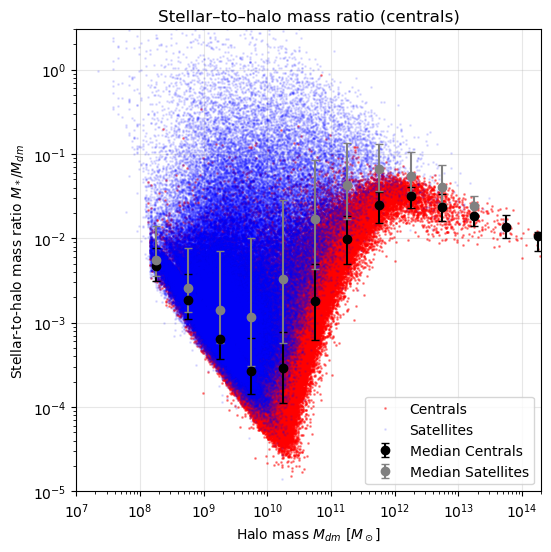

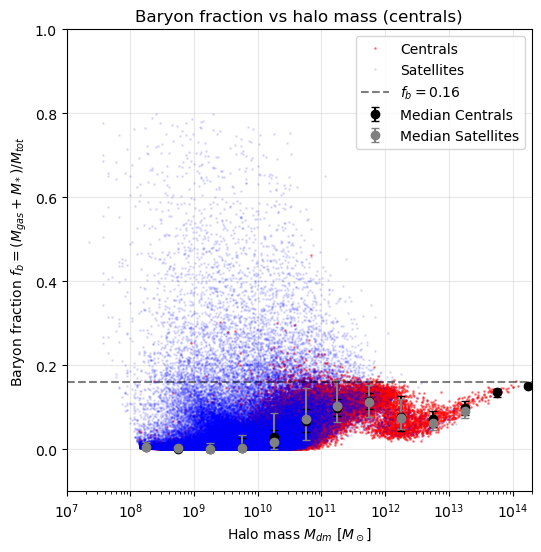

In [ ]:
#do analysis again

valid = (total_mass > 0) & (total_mass_type[:,1] > 0) & (total_mass_type[:,4] > 0)


# centrals only
mask_central = is_central[valid]
mask_s = is_satellite_final[valid]

Mdm_central = Mdm[mask_central]
Mstar_central = Mstar[mask_central]
Mgas_central  = Mgas[mask_central]
Mtot_central  = Mtot[mask_central]

#sattelites 
Mdm_s = Mdm[mask_s]
Mstar_s = Mstar[mask_s]
Mgas_s  = Mgas[mask_s]
Mtot_s = Mtot[mask_s]

#analysis on s

bin_width_dex = 0.5
logM_min = np.floor(np.log10(Mdm_central.min()))
logM_max = np.ceil(np.log10(Mdm_central.max()))
bin_edges = 10**np.arange(logM_min, logM_max + 1e-9, bin_width_dex)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])


def median_with_error(x, y, bins):
    medians, sigma_low, sigma_high = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x > lo) & (x <= hi)
        if np.sum(mask) < 5:
            medians.append(np.nan)
            sigma_low.append(np.nan)
            sigma_high.append(np.nan)
            continue
        val = y[mask]
        med = np.median(val)
        p16, p84 = np.percentile(val, [16, 84])
        medians.append(med)
        sigma_low.append(med - p16)
        sigma_high.append(p84 - med)
    return np.array(medians), np.array(sigma_low), np.array(sigma_high)

# Stellar-to-halo mass ratio
R_star = Mstar_central / Mdm_central
R_star_sat = Mstar_s/ Mdm_s

med_ratio, sigma_low, sigma_high = median_with_error(Mdm_central, R_star, bin_edges)
med_ratio_sat, sigma_low_sat, sigma_high_sat = median_with_error(Mdm_s, R_star_sat, bin_edges)

# Baryon fraction of central/satellite galaxies
fb_central = (Mstar_central + Mgas_central) / Mtot_central
fb_sat = (Mstar_s + Mgas_s)/Mtot_s

med_fb, sigma_fb_low, sigma_fb_high = median_with_error(Mdm_central, fb_central, bin_edges)
med_fb_sat, sigma_fb_low_sat, sigma_fb_high_sat = median_with_error(Mdm_s, fb_sat, bin_edges)


# ---------------------------
# 5) Plot Stellar-to-Halo Mass
# ---------------------------
plt.figure(figsize=(6,6))
plt.loglog(Mdm_central, R_star, '.', ms=2, alpha=0.4, color='red', label='Centrals')
plt.loglog(Mdm_s, R_star_sat, '.', ms=2, alpha=0.1, color='blue', label='Satellites')

plt.errorbar(bin_centers, med_ratio, yerr=[sigma_low, sigma_high],
             fmt='o', color='black', markersize=6, capsize=3, label='Median Centrals')
plt.errorbar(bin_centers, med_ratio_sat, yerr=[sigma_low_sat, sigma_high_sat],
             fmt='o', color='grey', markersize=6, capsize=3, label='Median Satellites')
plt.xlabel("Halo mass $M_{dm}$ [$M_\odot$]")
plt.ylabel("Stellar-to-halo mass ratio $M_*/M_{dm}$")
plt.title("Stellar–to–halo mass ratio (centrals)")
plt.xlim(1e7, 2e14)
plt.ylim(1e-5, 3)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ---------------------------
# 6) Plot Baryon Fraction
# ---------------------------

plt.figure(figsize=(6,6))
plt.semilogx(Mdm_central, fb_central, '.', ms=2, alpha=0.4, color='red', label='Centrals')
plt.semilogx(Mdm_s, fb_sat, '.', ms=2, alpha=0.1, color='blue', label='Satellites')

plt.errorbar(bin_centers, med_fb, yerr=[sigma_fb_low, sigma_fb_high],
             fmt='o', color='black', markersize=6, capsize=3, label='Median Centrals')
plt.errorbar(bin_centers, med_fb_sat, yerr=[sigma_fb_low_sat, sigma_fb_high_sat],
             fmt='o', color='grey', markersize=6, capsize=3, label='Median Satellites')
plt.axhline(y=0.16, alpha=0.5, ls='--', color='black', label=r'$f_{b} = 0.16$')
plt.xlabel("Halo mass $M_{dm}$ [$M_\odot$]")
plt.ylabel("Baryon fraction $f_b = (M_{gas}+M_*)/M_{tot}$")
plt.title("Baryon fraction vs halo mass (centrals)")
plt.xlim(1e7, 2e14)
plt.ylim(-0.1, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Part 3)

Possible relations:
- Star formation main sequence (SFR vs M_★)
- Mass–metallicity relation (gas-phase metallicity vs M_★)
- Size–mass relation (half-mass radius r_half vs M_★)
- Black hole mass — stellar mass (M_BH vs M_★)
- Satellite fraction vs host mass

### a) Star Formation Rate (SFR)

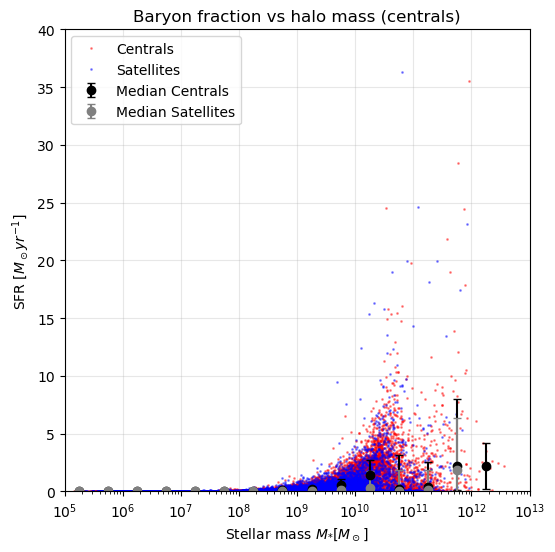

In [158]:
#redefine needed masks
mask   = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8) #consider for analysis (halo is suitable for analysis)
valid = (total_mass > 0) & (total_mass_type[:,1] > 0) & (total_mass_type[:,4] > 0)

#SFR in function of total mass
SFR_haloes = np.asarray(data['Subhalo']["SubhaloSFR"])
total_mass_all_haloes = np.asarray(data['Subhalo']["SubhaloMass"][:])*10**10/h

SFR_haloes_central = SFR_haloes[mask==1][valid][mask_central]
SFR_haloes_satellites = SFR_haloes[mask==1][valid][mask_s]

#define bins
bin_width_dex_SFR = 0.5
logM_min_SFR = np.floor(np.log10(Mstar_central.min()))
logM_max_SFR = np.ceil(np.log10(Mstar_central.max()))
bin_edges_SFR = 10**np.arange(logM_min_SFR, logM_max_SFR + 1e-9, bin_width_dex_SFR)
bin_central_SFR = np.sqrt(bin_edges_SFR[:-1] * bin_edges_SFR[1:])

med_SFR_central, sigma_low_SFR_central, sigma_high_SFR_central = median_with_error(Mstar_central, 
                                                                                   SFR_haloes_central, 
                                                                                   bin_edges_SFR)
med_SFR_sat, sigma_low_SFR_sat, sigma_high_SFR_sat = median_with_error(Mstar_s, 
                                                                       SFR_haloes_satellites, 
                                                                       bin_edges_SFR)

plt.figure(figsize=(6,6))

plt.semilogx(Mstar_central, SFR_haloes_central, '.', ms=2, alpha=0.4, color='red', label='Centrals')
plt.semilogx(Mstar_s, SFR_haloes_satellites, '.', ms=2, alpha=0.4, color='blue', label='Satellites')

plt.errorbar(bin_central_SFR, med_SFR_central, yerr=[sigma_low_SFR_central, sigma_high_SFR_central],
             fmt='o', color='black', markersize=6, capsize=3, label='Median Centrals')
plt.errorbar(bin_central_SFR, med_SFR_sat, yerr=[sigma_low_SFR_sat, sigma_high_SFR_sat],
             fmt='o', color='grey', markersize=6, capsize=3, label='Median Satellites')

plt.xlabel(r"Stellar mass $M_{*} [M_\odot]$")
plt.ylabel(r"SFR $[M_\odot yr^{-1}]$")
plt.title("Baryon fraction vs halo mass (centrals)")
plt.xlim(1e5, 1e13)
plt.ylim(-0.01, 40)
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.show()

### b) Black hole mass vs total mass

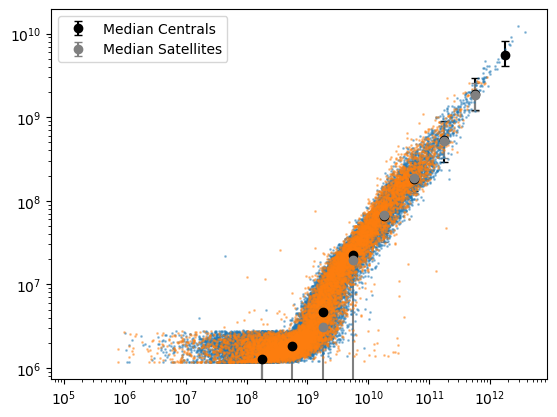

In [178]:
M_BH_central = Mbh[mask_central]
M_BH_sat = Mbh[mask_s]

#define bins
bin_width_dex_BH = 0.5
logM_min_BH = np.floor(np.log10(Mstar_central.min()))
logM_max_BH = np.ceil(np.log10(Mstar_central.max()))
bin_edges_BH = 10**np.arange(logM_min_BH, logM_max_BH + 1e-9, bin_width_dex_BH)
bin_central_BH = np.sqrt(bin_edges_BH[:-1] * bin_edges_BH[1:])

med_BH_central, sigma_low_BH_central, sigma_high_BH_central = median_with_error(Mstar_central, 
                                                                                   M_BH_central, 
                                                                                   bin_edges_BH)
med_BH_sat, sigma_low_BH_sat, sigma_high_BH_sat = median_with_error(Mstar_s, 
                                                                       M_BH_sat, 
                                                                       bin_edges_BH)

plt.errorbar(bin_central_BH, med_BH_central, yerr=[sigma_low_BH_central, sigma_high_BH_central],
             fmt='o', color='black', markersize=6, capsize=3, label='Median Centrals')
plt.errorbar(bin_central_BH, med_BH_sat, yerr=[sigma_low_BH_sat, sigma_high_BH_sat],
             fmt='o', color='grey', markersize=6, capsize=3, label='Median Satellites')

plt.loglog(Mstar_central,M_BH_central, '.', ms=2, alpha=0.4)
plt.loglog(Mstar_s,M_BH_sat, '.', ms=2, alpha=0.4)
plt.legend()
plt.show()